# Event Simulator

The goal of this notebook is to simulate the Key Project dynamic observing strategy for microlensing events. 
This strategy depends on the event timescale:
* A>80: continuous monitoring
* Short timescale events, $t_{\rm{E}}<100$ days: hourly monitoring in the wings, every 15min over the peak
* Long timescale events, $t_{\rm{E}}>=100$ days: daily monitoring in the wings, every 1hr over the peak

The objective is to use the simulated lightcurves to estimate the required observing time. 

In [1]:
import numpy as np
from astropy.io import fits
from astropy.table import Table, Column
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.time import Time
import healpy as hp
import random
import matplotlib.pyplot as plt
import csv
from pyLIMA.simulations import simulator
from pyLIMA import event, toolbox
from pyLIMA import fits as pyLIMA_fits
from pyLIMA import telescopes
from pyLIMA.models import PSPL_model
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.toolbox import fake_telescopes
from pyLIMA.toolbox import plots as pyLIMA_plots_toolbox
import visibility_utils
import healpixel_functions
from scipy import interpolate
import h5py
import copy

# Defining event phases and dynamic cadence

In [2]:
# Location of a Bulge event as a default
location = {
    'RA': 270.0,
    'Dec': -18.5
}

In [3]:
# PSPL event parameters
params = {
    't0': 2461146.36, 
    'u0': 0.05, 
    'tE': 100,
    'piEN': 0.3,
    'piEE': 0.1
}

In [4]:
mag_baseline = 18.5
g = 0.0 # unblended

In [5]:
# Initial high density continuous timeseries lightcurve for modeling purposes 
cadence = 3600.0 / (60*60*24) # s -> days
t_start = params['t0'] - params['tE']*2.0
t_end = params['t0'] + params['tE']*2.0
ts = np.arange(t_start, t_end, cadence)

timeseries = np.zeros((len(ts),3))
timeseries[:,0] = ts 
timeseries[:,1] = [mag_baseline]*len(ts) 
timeseries[:,2] = [0.01]*len(ts)
timeseries

array([[2.46094636e+06, 1.85000000e+01, 1.00000000e-02],
       [2.46094640e+06, 1.85000000e+01, 1.00000000e-02],
       [2.46094644e+06, 1.85000000e+01, 1.00000000e-02],
       ...,
       [2.46134623e+06, 1.85000000e+01, 1.00000000e-02],
       [2.46134628e+06, 1.85000000e+01, 1.00000000e-02],
       [2.46134632e+06, 1.85000000e+01, 1.00000000e-02]], shape=(9600, 3))

In [6]:
def simulate_event(location, params, timeseries):
    mulens = event.Event(ra=location['RA'], dec=location['Dec'])
    mulens.name = 'Simulated event'

    tel_i = telescopes.Telescope(name='i', camera_filter='i', location='Earth', lightcurve=timeseries.astype(float),
                              lightcurve_names = ['time','mag','err_mag'],lightcurve_units = ['JD','mag','mag'])

    mulens.telescopes.append(tel_i)

    mulens.telescopes[0].ld_gamma = 0.5

    # Limiting magnitude
    ZP = 27.4
    
    mulens_parameters = []
    for key in params:
        mulens_parameters.append(params[key])
    print('Model parameters: ', mulens_parameters)
    
    mulens_model = PSPL_model.PSPLmodel(mulens ,parallax=['Full', params['t0']])
    mulens_pyLIMA_parameters = mulens_model.compute_pyLIMA_parameters(mulens_parameters)
    print('PyLIMA parameters: ', mulens_pyLIMA_parameters) 
    
    mulens_flux_parameters = []

    flux_baseline = 10**((ZP-mag_baseline)/2.5)
    f_source = flux_baseline/(1+g)
    f_blend = 0.0
    f_total = f_source + f_blend 

    mulens_flux_parameters.append(f_source)
    mulens_flux_parameters.append(f_total)

    mulens_parameters += mulens_flux_parameters
    print('Mulens parameters: ', mulens_parameters)
    mulens_pyLIMA_parameters = mulens_model.compute_pyLIMA_parameters(mulens_parameters)
    print(mulens_pyLIMA_parameters)
    simulator.simulate_lightcurve(mulens_model, mulens_pyLIMA_parameters)
    print('Simulated lightcurve') 
    
    model_flux = mulens_model.compute_the_microlensing_model(mulens.telescopes[0],
                                                             mulens_pyLIMA_parameters)['photometry']
    mulens.telescopes[0].lightcurve['flux'] = model_flux
    print('Model flux: ', model_flux)
    
    # Generate a well-sampled lightcurve model for plotting
    #model_telescope = pyLIMA_plots.create_telescopes_to_plot_model(mulens_model, mulens_pyLIMA_parameters)[0]

    return mulens_model, mulens_parameters

In [7]:
mulens_model, mulens_parameters = simulate_event(location, params, timeseries)

Model parameters:  [2461146.36, 0.05, 100, 0.3, 0.1]
Parallax(Full) estimated for the telescope i: SUCCESS
PyLIMA parameters:  OrderedDict({'t0': 2461146.36, 'u0': 0.05, 'tE': 100, 'piEN': 0.3, 'piEE': 0.1, 'fsource_i': None, 'ftotal_i': None})
Mulens parameters:  [2461146.36, 0.05, 100, 0.3, 0.1, 3630.78054770101, 3630.78054770101]
OrderedDict({'t0': 2461146.36, 'u0': 0.05, 'tE': 100, 'piEN': 0.3, 'piEE': 0.1, 'fsource_i': 3630.78054770101, 'ftotal_i': 3630.78054770101})
Parallax(Full) estimated for the telescope i: SUCCESS
Simulated lightcurve
Model flux:  [3747.44872584 3747.51333829 3747.57800995 ... 3899.6226131  3899.43398675
 3899.24548684]


In [8]:
# PyLIMA plotting function extracted and stripped-down for current purposes
MARKER_SYMBOLS = np.array(
    [['o', '.', '*', 'v', '^', '<', '>', 's', 'p', 'd', 'x'] * 10])
MARKERS_COLORS = plt.rcParams["axes.prop_cycle"]

PLOT_SYMBOLS = ['o', '.', '*', 'v', '^', '<', '>', 's', 'p', 'd', 'x']
PLOT_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

LS4_PLOT_COLORS = {
    'LS4_g': '#ff7f0e', 
    'LS4_i': '#d62728', 
    'LS4_z': '#9467bd'
}


def plot_aligned_data(figure_axe, microlensing_model, model_parameters, bokeh_plot=None,
                      plot_unit='Mag'):
    pyLIMA_parameters = microlensing_model.compute_pyLIMA_parameters(model_parameters)

    # plot aligned data
    index = 0

    list_of_telescopes = pyLIMA_plots.create_telescopes_to_plot_model(microlensing_model,
                                                         pyLIMA_parameters)

    ref_names = []
    ref_locations = []
    ref_magnification = []
    ref_fluxes = []

    for ref_tel in list_of_telescopes:
        if ref_tel.lightcurve is not None:
            model_magnification = microlensing_model.model_magnification(ref_tel,
                                                                         pyLIMA_parameters)

            microlensing_model.derive_telescope_flux(ref_tel, pyLIMA_parameters,
                                                     model_magnification)

            f_source = pyLIMA_parameters['fsource_' + ref_tel.name]
            f_blend = pyLIMA_parameters['fblend_' + ref_tel.name]

            # model_magnification = (model['photometry']-f_blend)/f_source

            ref_names.append(ref_tel.name)
            ref_locations.append(ref_tel.location)
            ref_magnification.append(model_magnification)
            ref_fluxes.append([f_source, f_blend])

    normalized_lc = {} 
    
    for ind, tel in enumerate(microlensing_model.event.telescopes):

        if tel.lightcurve is not None:

            if tel.location == 'Earth':

                ref_index = np.where(np.array(ref_locations) == 'Earth')[0][0]

            else:

                ref_index = np.where(np.array(ref_names) == tel.name)[0][0]

            residus_in_mag = \
                pyLIMA_fits.objective_functions.photometric_residuals_in_magnitude(
                    tel, microlensing_model,
                    pyLIMA_parameters)
            if ind == 0:
                reference_source = ref_fluxes[ind][0]
                reference_blend = ref_fluxes[ind][1]
                index += 1

            # time_mask = [False for i in range(len(ref_magnification[ref_index]))]
            time_mask = []

            for time in tel.lightcurve['time'].value:
                time_index = np.where(list_of_telescopes[ref_index].lightcurve[
                                          'time'].value == time)[0][0]
                time_mask.append(time_index)

            # model_flux = ref_fluxes[ref_index][0] * ref_magnification[ref_index][
            #    time_mask] + ref_fluxes[ref_index][1]
            model_flux = reference_source * ref_magnification[ref_index][
                time_mask] + reference_blend
            magnitude = toolbox.brightness_transformation.ZERO_POINT - 2.5 * \
                        np.log10(model_flux)

            ind_color = ind%len(MARKERS_COLORS.by_key()["color"])
            color = MARKERS_COLORS.by_key()["color"][ind_color]
            marker = str(MARKER_SYMBOLS[0][ind])

            #pyLIMA_plots_toolbox.plot_light_curve_magnitude(tel.lightcurve['time'].value,
            #                                 magnitude + residus_in_mag,
            #                                 tel.lightcurve['err_mag'].value,
            #                                 figure_axe=figure_axe, color=color,
            #                                 marker=marker, name=tel.name)
            mask = np.isfinite(tel.lightcurve['err_mag'].value)
            mags = magnitude[mask] + residus_in_mag[mask]

            mag_err = tel.lightcurve['err_mag'].value[mask]
            
            normalized_lc[tel] = Table([
                Column(name='time', data=tel.lightcurve['time'].value[mask]),
                Column(name='mag', data=mags),
                Column(name='mag_err', data=mag_err)
            ])
    return normalized_lc, model_magnification

In [9]:
def plot_photometric_models(figure_axe, microlensing_model, model_parameters,
                            bokeh_plot=None, plot_unit='Mag'):
    pyLIMA_parameters = microlensing_model.compute_pyLIMA_parameters(model_parameters)

    list_of_telescopes = pyLIMA_plots.create_telescopes_to_plot_model(microlensing_model,
                                                         pyLIMA_parameters)
    telescopes_names = np.array([i.name for i in microlensing_model.event.telescopes])

    # plot models
    index = 0
    model_lc = {}
    
    for tel in list_of_telescopes:

        if tel.lightcurve is not None:

            magni = microlensing_model.model_magnification(tel, pyLIMA_parameters)
            microlensing_model.derive_telescope_flux(tel, pyLIMA_parameters, magni)

            f_source = pyLIMA_parameters['fsource_' + tel.name]
            f_blend = pyLIMA_parameters['fblend_' + tel.name]

            if index == 0:
                ref_source = f_source
                ref_blend = f_blend
                index += 1

            magnitude =  toolbox.brightness_transformation.ZERO_POINT - 2.5 * \
                        np.log10(ref_source * magni + ref_blend)

            # delta_mag = -2.5 * np.log10(f_source + f_blend) + 2.5 * np.log10(
            ##     ref_source + ref_blend)
            # magnitude -= delta_mag

            name = tel.name

            index_color = np.where(name == telescopes_names)[0][0]
            color = MARKERS_COLORS.by_key()["color"][index_color]

            if tel.location == 'Earth':

                name = tel.location
                linestyle = '-'

            else:

                linestyle = '--'


            model_lc[tel.name] = Table([
                Column(name='time', data=tel.lightcurve['time'].value),
                Column(name='mag', data=magnitude)
            ])

    return model_lc

Parallax(Full) estimated for the telescope i: SUCCESS


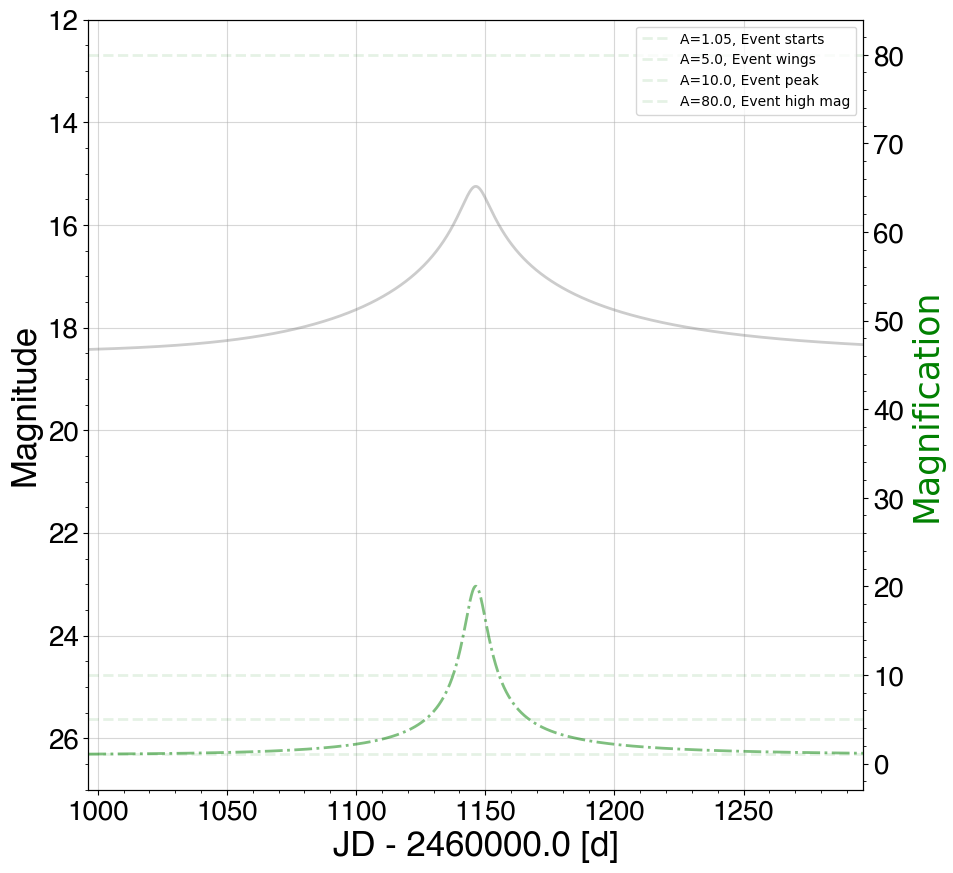

In [10]:
fig2, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))
toffset = 2460000.0
normalized_lc, model_magnification = plot_aligned_data(ax1, mulens_model, mulens_parameters, bokeh_plot=None, plot_unit='Mag')

model_lc = plot_photometric_models(ax1, mulens_model, mulens_parameters,
                            bokeh_plot=None, plot_unit='Mag')

ax1.plot(model_lc['i']['time']-toffset, model_lc['i']['mag'], ls='-', lw=2, c='grey', alpha=0.4) 

ax2 = ax1.twinx() 

ax2.plot(model_lc['i']['time']-toffset, model_magnification, ls='-.', lw=2, c='green', alpha=0.5) 

xmin = params['t0']-(300/2.0)-toffset
xmax = params['t0']+(300/2.0)-toffset
ax1.set_xlim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ymax = 12.0
ymin = 27.0
ax1.set_ylim(ymin, ymax)

# Magnification thresholds
a_thresholds = {
    'Event starts': 1.05,
    'Event wings': 5.0,
    'Event peak': 10.0,
    'Event high mag': 80.0
}

for label, a in a_thresholds.items():
    ax2.plot([xmin, xmax], [a,a], ls='--', lw=2, c='green', alpha=0.1, label='A='+str(a)+', '+label)

ax1.set_xlabel('JD - 2460000.0 [d]', fontsize=25, fontname="Helvetica", fontweight='ultralight')
ax1.set_ylabel('Magnitude', fontsize=25, fontname="Helvetica", fontweight='ultralight')
ax2.set_ylabel('Magnification', fontsize=25, color='green')
ax2.legend(loc='upper right')

ax1.tick_params(axis='both', labelsize=20, labelfontfamily="Helvetica") 
ax2.tick_params(axis='both', labelsize=20, labelfontfamily="Helvetica") 
ax1.minorticks_on() 
ax2.minorticks_on() 
ax1.grid(alpha=0.5)


We can use these magnification-related thresholds to calculate when the event is in the wings versus the peak and apply the corresponding cadence.  

Calculate the length of time spend in the wings versus the peak versus high mag. 

We use the symmetry of the lightcurve to simplify the calculation.

In [73]:
def calc_lc_phases(model_lc, model_magnification, params):
    idx = np.where(model_lc['i']['time'] <= params['t0'])

    half_lc_magnification = model_magnification[idx]

    # Find timestamps in the wings of the event, A = 5 - 10. 
    jdx = np.where((half_lc_magnification >= 5.0) & (half_lc_magnification <= 10.0))[0]
    ts_wings = model_lc['i']['time'][jdx]
    time_wings = (ts_wings.max() - ts_wings.min()) * 2.0
    
    # Find timestamps in the peak of the event, A = 10 - 80.
    jdx = np.where((half_lc_magnification >= 10.0) & (half_lc_magnification <= 80.0))[0]
    ts_peak = model_lc['i']['time'][jdx]
    time_peak = (ts_peak.max() - ts_peak.min()) * 2.0
    
    # Find timestamps at high mag, A > 80
    jdx = np.where(half_lc_magnification >= 80.0)[0]
    if len(jdx) > 0:
        time_high = 0.5 # days -> 12hrs
        print('Time at high mag = ' + str(round(time_high,1)) + 'd')
        # High mag strategy focusses just around the peak 
        time_wings = 0.0
        time_peak = 1.0
        print('Time at peak = ' + str(round(time_peak,2)) + 'd')
    else:
        time_high = 0.0
        print('Event did not reach high mag')
    
    print('Time in wings = ' + str(round(time_wings,1)) + 'd')
    print('Time in peak = ' + str(round(time_peak,1)) + 'd')

    return time_wings, time_peak, time_high

In [74]:
time_wings, time_peak, time_high = calc_lc_phases(model_lc, model_magnification, params)

Time at high mag = 0.5d
Time at peak = 1.0d
Time in wings = 0.0d
Time in peak = 1.0d


Observing cadences for the different phases of the event will be as follows:

In [101]:
def get_cadences(params):
    """Cadences = number of observations per 24hrs"""

    # Short timescale events:
    if params['tE'] < 100.0: 
        print('Event has a short timescale: ' + str(params['tE']) + 'd')
        cadence_wings = 12.0  # Every 2 hrs
        cadence_peak = 4.0 * 12.0 # Every 15min
    
    # Long timescale events
    else:
        print('Event has a long timescale: ' + str(params['tE']) + 'd')
        cadence_wings = 1.0  # Daily
        cadence_peak = 1.0 * 24.0 # Hourly

    return cadence_wings, cadence_peak

In [102]:
cadence_wings, cadence_peak = get_cadences(params)

Event has a short timescale: 30d


Now calculate the amount of time required for the event.  The observing time required depends on the brightness of the event, and ranges from 30-300s.  

In [103]:
def calc_obs_time(params, time_wings, time_peak, time_high):
    exptime_wings = 300 # seconds
    exptime_peak = 30 # seconds
    overhead = 28 # seconds

    obs_time = (
        (time_wings * cadence_wings * (exptime_wings+overhead)) 
        + (time_peak * cadence_peak * (exptime_peak+overhead))
        + time_high * 24.0*60.0*60.0    
    ) / 3600.0
    print('Time taken for observations = ' + str(round(obs_time, 0)) + 'hrs')

In [104]:
obs_time = calc_obs_time(params, time_wings, time_peak, time_high)

Time taken for observations = 13.0hrs


## Time required for different event categories

### Long timescale event

In [105]:
# Location of a Bulge event as a default
location = {
    'RA': 270.0,
    'Dec': -18.5
}

In [106]:
# Long timescale event
params = {
    't0': 2461146.36, 
    'u0': 0.05, 
    'tE': 100,
    'piEN': 0.3,
    'piEE': 0.1
}

In [107]:
# Initial high density continuous timeseries lightcurve for modeling purposes 
cadence = 3600.0 / (60*60*24) # s -> days
t_start = params['t0'] - params['tE']*2.0
t_end = params['t0'] + params['tE']*2.0
ts = np.arange(t_start, t_end, cadence)

timeseries = np.zeros((len(ts),3))
timeseries[:,0] = ts 
timeseries[:,1] = [mag_baseline]*len(ts) 
timeseries[:,2] = [0.01]*len(ts)

In [108]:
mulens_model, mulens_parameters = simulate_event(location, params, timeseries)

Model parameters:  [2461146.36, 0.05, 100, 0.3, 0.1]
Parallax(Full) estimated for the telescope i: SUCCESS
PyLIMA parameters:  OrderedDict({'t0': 2461146.36, 'u0': 0.05, 'tE': 100, 'piEN': 0.3, 'piEE': 0.1, 'fsource_i': None, 'ftotal_i': None})
Mulens parameters:  [2461146.36, 0.05, 100, 0.3, 0.1, 3630.78054770101, 3630.78054770101]
OrderedDict({'t0': 2461146.36, 'u0': 0.05, 'tE': 100, 'piEN': 0.3, 'piEE': 0.1, 'fsource_i': 3630.78054770101, 'ftotal_i': 3630.78054770101})
Parallax(Full) estimated for the telescope i: SUCCESS
Simulated lightcurve
Model flux:  [3747.44872584 3747.51333829 3747.57800995 ... 3899.6226131  3899.43398675
 3899.24548684]


In [109]:
normalized_lc, model_magnification = plot_aligned_data(ax1, mulens_model, mulens_parameters, bokeh_plot=None, plot_unit='Mag')

model_lc = plot_photometric_models(ax1, mulens_model, mulens_parameters,
                            bokeh_plot=None, plot_unit='Mag')

Parallax(Full) estimated for the telescope i: SUCCESS


In [110]:
time_wings, time_peak, time_high = calc_lc_phases(model_lc, model_magnification, params)

Event did not reach high mag
Time in wings = 21.3d
Time in peak = 17.5d


In [111]:
cadence_wings, cadence_peak = get_cadences(params)

Event has a long timescale: 100d


In [112]:
obs_time = calc_obs_time(params, time_wings, time_peak, time_high)

Time taken for observations = 9.0hrs


### Stellar/planetary event
Non-high mag case

In [113]:
# Stellar/planetary timescale event
params = {
    't0': 2461146.36, 
    'u0': 0.05, 
    'tE': 45,
    'piEN': 0.3,
    'piEE': 0.1
}

In [114]:
# Initial high density continuous timeseries lightcurve for modeling purposes 
cadence = 3600.0 / (60*60*24) # s -> days
t_start = params['t0'] - params['tE']*2.0
t_end = params['t0'] + params['tE']*2.0
ts = np.arange(t_start, t_end, cadence)

timeseries = np.zeros((len(ts),3))
timeseries[:,0] = ts 
timeseries[:,1] = [mag_baseline]*len(ts) 
timeseries[:,2] = [0.01]*len(ts)

In [115]:
mulens_model, mulens_parameters = simulate_event(location, params, timeseries)

Model parameters:  [2461146.36, 0.05, 45, 0.3, 0.1]
Parallax(Full) estimated for the telescope i: SUCCESS
PyLIMA parameters:  OrderedDict({'t0': 2461146.36, 'u0': 0.05, 'tE': 45, 'piEN': 0.3, 'piEE': 0.1, 'fsource_i': None, 'ftotal_i': None})
Mulens parameters:  [2461146.36, 0.05, 45, 0.3, 0.1, 3630.78054770101, 3630.78054770101]
OrderedDict({'t0': 2461146.36, 'u0': 0.05, 'tE': 45, 'piEN': 0.3, 'piEE': 0.1, 'fsource_i': 3630.78054770101, 'ftotal_i': 3630.78054770101})
Parallax(Full) estimated for the telescope i: SUCCESS
Simulated lightcurve
Model flux:  [3813.62731126 3813.89513909 3814.16343089 ... 3880.60150276 3880.27639595
 3879.95179569]


In [116]:
normalized_lc, model_magnification = plot_aligned_data(ax1, mulens_model, mulens_parameters, bokeh_plot=None, plot_unit='Mag')

model_lc = plot_photometric_models(ax1, mulens_model, mulens_parameters,
                            bokeh_plot=None, plot_unit='Mag')

Parallax(Full) estimated for the telescope i: SUCCESS


In [117]:
time_wings, time_peak, time_high = calc_lc_phases(model_lc, model_magnification, params)

Event did not reach high mag
Time in wings = 9.8d
Time in peak = 7.8d


In [118]:
cadence_wings, cadence_peak = get_cadences(params)

Event has a short timescale: 45d


In [119]:
obs_time = calc_obs_time(params, time_wings, time_peak, time_high)

Time taken for observations = 17.0hrs


### High mag event

In [120]:
# Stellar/planetary timescale event
params = {
    't0': 2461146.36, 
    'u0': 0.005, 
    'tE': 30,
    'piEN': 0.3,
    'piEE': 0.1
}

In [121]:
# Initial high density continuous timeseries lightcurve for modeling purposes 
cadence = 3600.0 / (60*60*24) # s -> days
t_start = params['t0'] - params['tE']*2.0
t_end = params['t0'] + params['tE']*2.0
ts = np.arange(t_start, t_end, cadence)

timeseries = np.zeros((len(ts),3))
timeseries[:,0] = ts 
timeseries[:,1] = [mag_baseline]*len(ts) 
timeseries[:,2] = [0.01]*len(ts)

In [122]:
mulens_model, mulens_parameters = simulate_event(location, params, timeseries)

Model parameters:  [2461146.36, 0.005, 30, 0.3, 0.1]
Parallax(Full) estimated for the telescope i: SUCCESS
PyLIMA parameters:  OrderedDict({'t0': 2461146.36, 'u0': 0.005, 'tE': 30, 'piEN': 0.3, 'piEE': 0.1, 'fsource_i': None, 'ftotal_i': None})
Mulens parameters:  [2461146.36, 0.005, 30, 0.3, 0.1, 3630.78054770101, 3630.78054770101]
OrderedDict({'t0': 2461146.36, 'u0': 0.005, 'tE': 30, 'piEN': 0.3, 'piEE': 0.1, 'fsource_i': 3630.78054770101, 'ftotal_i': 3630.78054770101})
Parallax(Full) estimated for the telescope i: SUCCESS
Simulated lightcurve
Model flux:  [3833.19695625 3833.62386442 3834.05183998 ... 3866.69716538 3866.23131817
 3865.76658084]


In [123]:
normalized_lc, model_magnification = plot_aligned_data(ax1, mulens_model, mulens_parameters, bokeh_plot=None, plot_unit='Mag')

model_lc = plot_photometric_models(ax1, mulens_model, mulens_parameters,
                            bokeh_plot=None, plot_unit='Mag')

Parallax(Full) estimated for the telescope i: SUCCESS


In [124]:
time_wings, time_peak, time_high = calc_lc_phases(model_lc, model_magnification, params)

Time at high mag = 0.5d
Time at peak = 1.0d
Time in wings = 0.0d
Time in peak = 1.0d


In [125]:
cadence_wings, cadence_peak = get_cadences(params)

Event has a short timescale: 30d


In [126]:
obs_time = calc_obs_time(params, time_wings, time_peak, time_high)

Time taken for observations = 13.0hrs
